# Alternative Data Test v5 — With Optuna Tuning

**Three experiments, each with its own Optuna hyperparameter search:**
1. **FRED-MD only** (baseline) — should reproduce ~52.7%
2. **FRED-MD + Alternative Data** — 80 features
3. **Alternative Data ONLY** — 49 features, no FRED-MD

Uses the **exact BiGRUClassifier and CV pipeline** from the working classification notebook.

In [1]:
!pip install optuna --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 34.9 MB/s eta 0:00:00


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random, pickle, warnings, os
from pathlib import Path
import seaborn as sns
import optuna
import tensorflow as tf
from tensorflow.keras import layers, regularizers, Input, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, classification_report)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import TimeSeriesSplit
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.style.use('seaborn-v0_8-whitegrid')
random.seed(42); np.random.seed(42); tf.random.set_seed(42)
print('Imports loaded.')

Imports loaded.


In [3]:
from google.colab import drive
drive.mount('/content/drive')
BASE_DIR = Path('/content/drive/MyDrive/Quants ')
ALT_DIR = BASE_DIR / 'alternative_data' / 'raw'

Mounted at /content/drive


## 1. Load All Data (identical to v4)

In [4]:
# === WHEAT PRICES ===
W18 = BASE_DIR / 'Investing.com' / 'US Wheat Futures Historical Data_2018.csv'
W25 = BASE_DIR / 'Investing.com' / 'US Wheat Futures Historical Data_2025.csv'
def load_price(p):
    df = pd.read_csv(p)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').set_index('Date')
    df['Price'] = df['Price'].astype(str).str.replace(',','',regex=False).astype(float)
    return df['Price']
p1, p2 = load_price(W18), load_price(W25)
df_price = pd.concat([p1, p2.iloc[1:]]).pipe(lambda s: s[~s.index.duplicated(keep='last')]).sort_index()
df_price.name = 'Price'
print(f'Wheat prices: {len(df_price)} days')

# === FRED-MD ===
fred_md_path = str(BASE_DIR / 'FredMD_Dataset' / '2025-10-MD.csv')
tcodes_row = pd.read_csv(fred_md_path, nrows=1)
fred_raw = pd.read_csv(fred_md_path, skiprows=[1])
fred_raw['sasdate'] = pd.to_datetime(fred_raw['sasdate'], format='%m/%d/%Y')
fred_raw = fred_raw.set_index('sasdate').sort_index()
features_31 = ['RPI','W875RX1','CMRMTSPLx','IPFPNSS','USWTRADE','USTRADE',
    'BUSLOANS','CONSPI','S&P 500','S&P PE ratio','FEDFUNDS','TB3MS',
    'TB6MS','GS1','GS5','GS10','AAA','BAA','TB3SMFFM','TB6SMFFM',
    'T1YFFM','T5YFFM','T10YFFM','AAAFFM','BAAFFM',
    'EXSZUSx','EXJPUSx','EXUSUKx','EXCAUSx','PPICMM','UMCSENTx']
tcode_map = {c: int(float(tcodes_row[c].values[0])) for c in features_31}
def apply_tcode(s, tc):
    if tc==1: return s
    if tc==2: return s.diff()
    if tc==3: return s.diff().diff()
    if tc==4: return np.log(s.clip(lower=1e-10))
    if tc==5: return np.log(s.clip(lower=1e-10)).diff()
    if tc==6: return np.log(s.clip(lower=1e-10)).diff().diff()
    if tc==7: return (s/s.shift(1)-1).diff()
    return s
fs = fred_raw[features_31].copy().apply(pd.to_numeric, errors='coerce')
for c in features_31: fs[c] = apply_tcode(fs[c], tcode_map[c])
fred_t = fs.dropna().replace([np.inf,-np.inf], np.nan).dropna()
fred_t.index = fred_t.index + pd.DateOffset(months=1)
daily_idx = pd.date_range(fred_t.index.min(), fred_t.index.max()+pd.offsets.MonthEnd(0), freq='D')
df_macro = fred_t.reindex(daily_idx).ffill()
print(f'FRED-MD: {df_macro.shape}')

Wheat prices: 6864 days
FRED-MD: (17351, 31)


In [5]:
# === ALTERNATIVE DATA ===
# Tech indicators
inv_dir = BASE_DIR / 'Investing.com'
all_wf = sorted([f for f in inv_dir.iterdir() if f.suffix=='.csv' and 'Wheat' in f.name])
wfull = pd.concat([pd.read_csv(f) for f in all_wf], ignore_index=True)
wfull['Date'] = pd.to_datetime(wfull['Date'], format='mixed', dayfirst=False)
wfull = wfull.sort_values('Date').drop_duplicates(subset='Date').set_index('Date')
for c in ['Price','Open','High','Low']:
    wfull[c] = pd.to_numeric(wfull[c].astype(str).str.replace(',',''), errors='coerce')
def pvol(v):
    v=str(v).strip().replace(',','')
    if v.endswith('K'): return float(v[:-1])*1000
    elif v.endswith('M'): return float(v[:-1])*1e6
    try: return float(v)
    except: return np.nan
wfull['Volume'] = wfull['Vol.'].apply(pvol)

c,h,l,v = wfull['Price'],wfull['High'],wfull['Low'],wfull['Volume'].fillna(0)
tech = pd.DataFrame(index=wfull.index)
for n in [5,10,20]: tech[f'mom_{n}d'] = c.pct_change(n)
d=c.diff(); g=d.clip(lower=0); lo=(-d).clip(lower=0)
tech['rsi']=100-(100/(1+g.rolling(14).mean()/lo.rolling(14).mean().replace(0,np.nan)))
e12,e26=c.ewm(span=12).mean(),c.ewm(span=26).mean()
macd=e12-e26; tech['macd']=macd; tech['macd_hist']=macd-macd.ewm(span=9).mean()
s20,st20=c.rolling(20).mean(),c.rolling(20).std()
tech['bb_pctb']=(c-(s20-2*st20))/(4*st20).replace(0,np.nan)
tr=pd.concat([h-l,(h-c.shift(1)).abs(),(l-c.shift(1)).abs()],axis=1).max(axis=1)
tech['atr']=tr.rolling(14).mean()
tech['vol_sma']=v/v.rolling(20).mean().replace(0,np.nan)
print(f'Tech: {tech.columns.tolist()}')

# COT
cr=pd.read_csv(ALT_DIR/'cot_wheat_disaggregated.csv')
cr['Date']=pd.to_datetime(cr['Report_Date_as_YYYY-MM-DD'])
nc=['Open_Interest_All','Prod_Merc_Positions_Long_All','Prod_Merc_Positions_Short_All','M_Money_Positions_Long_All','M_Money_Positions_Short_All']
for c2 in nc: cr[c2]=pd.to_numeric(cr[c2],errors='coerce')
cot=cr.groupby('Date')[nc].sum().reset_index()
oi=cot['Open_Interest_All'].replace(0,np.nan)
cot['mm_net']=cot['M_Money_Positions_Long_All']-cot['M_Money_Positions_Short_All']
cot['cm_net']=cot['Prod_Merc_Positions_Long_All']-cot['Prod_Merc_Positions_Short_All']
cot['hedge_pr']=cot['cm_net']/oi; cot['spec_se']=cot['mm_net']/oi
cot['pos_chg']=cot['mm_net'].diff(4)
cot['spec_z']=(cot['mm_net']-cot['mm_net'].rolling(52).mean())/cot['mm_net'].rolling(52).std().replace(0,np.nan)
cot['oi_lev']=cot['Open_Interest_All']
cot_features=['hedge_pr','spec_se','pos_chg','spec_z','oi_lev']
cot['Date']=cot['Date']+pd.Timedelta(days=3)
cot_daily=cot.set_index('Date')[cot_features].resample('D').ffill()
print(f'COT: {len(cot_daily)} rows')

# Cross-commodity
ca={'corn_futures.csv':'corn','soybean_futures.csv':'soy','crude_oil_wti.csv':'oil','usd_index.csv':'usd','gold_futures.csv':'gold'}
cdfs=[]
for fn,lb2 in ca.items():
    dd=pd.read_csv(ALT_DIR/fn,header=[0,1],index_col=0,parse_dates=True)
    dd.columns=[c3[0] for c3 in dd.columns]; dd=dd.reset_index()
    dd['Date']=pd.to_datetime(dd['Date']); dd[f'{lb2}_cl']=pd.to_numeric(dd['Close'],errors='coerce')
    cdfs.append(dd[['Date',f'{lb2}_cl']].dropna().set_index('Date'))
xc=cdfs[0]
for dd in cdfs[1:]: xc=xc.join(dd,how='outer')
xc=xc.sort_index().ffill().dropna()
xc=xc.join(df_price,how='inner')
xc['wc_rat']=xc['Price']/xc['corn_cl'].replace(0,np.nan)
xc['ws_rat']=xc['Price']/xc['soy_cl'].replace(0,np.nan)
xc['wc_m20']=xc['wc_rat'].pct_change(20);xc['ws_m20']=xc['ws_rat'].pct_change(20)
wr2=xc['Price'].pct_change(10)
xc['rel_cn']=wr2-xc['corn_cl'].pct_change(10);xc['rel_ol']=wr2-xc['oil_cl'].pct_change(10)
xc['usd_c10']=xc['usd_cl'].pct_change(10);xc['gld_c10']=xc['gold_cl'].pct_change(10)
cross_fcols=['wc_rat','ws_rat','wc_m20','ws_m20','rel_cn','rel_ol','usd_c10','gld_c10']
cross_daily=xc[cross_fcols]
print(f'Cross: {len(cross_daily)} rows')

# Trends, Weather, Fear, NASA
gt=pd.read_csv(ALT_DIR/'google_trends.csv',parse_dates=['Date'],index_col='Date')
gt_cols=[c4 for c4 in gt.columns if c4!='isPartial']; gt=gt[gt_cols].resample('D').ffill()
wk=pd.read_csv(ALT_DIR/'weather_kansas.csv',parse_dates=['Date'],index_col='Date')
wnd=pd.read_csv(ALT_DIR/'weather_north_dakota.csv',parse_dates=['Date'],index_col='Date')
weather=wk.join(wnd,how='outer',lsuffix='',rsuffix='').sort_index().ffill().dropna()
vix=pd.read_csv(ALT_DIR/'vix.csv',parse_dates=['Date'],index_col='Date')
ovx=pd.read_csv(ALT_DIR/'ovx.csv',parse_dates=['Date'],index_col='Date')
fear=vix.join(ovx,how='outer').sort_index().ffill().dropna()
nasa=pd.read_csv(ALT_DIR/'nasa_power_ag.csv',parse_dates=['Date'],index_col='Date').dropna()
print(f'Trends:{len(gt)} Weather:{len(weather)} Fear:{len(fear)} NASA:{len(nasa)}')

Tech: ['mom_5d', 'mom_10d', 'mom_20d', 'rsi', 'macd', 'macd_hist', 'bb_pctb', 'atr', 'vol_sma']
COT: 4740 rows
Cross: 4514 rows
Trends:5814 Weather:5844 Fear:4528 NASA:5844


## 2. Build Three Feature DataFrames

In [6]:
# All alternative features combined
alt_data = tech.copy()
for df in [cot_daily, cross_daily, gt, weather, fear, nasa]:
    alt_data = alt_data.join(df, how='outer')
alt_data = alt_data.sort_index().ffill().bfill().replace([np.inf,-np.inf],np.nan).ffill().bfill()
print(f'All alt features: {len(alt_data.columns)} cols')

# A. Baseline: FRED-MD only
df_A = df_macro.join(df_price, how='inner').loc['2008-01-01':]
cols_A = [c5 for c5 in df_A.columns if c5!='Price'] + ['Price']
df_A = df_A[cols_A]

# B. FRED-MD + Alt
df_B = df_macro.join(alt_data, how='outer').ffill().bfill()
df_B = df_B.join(df_price, how='inner').loc['2008-01-01':]
cols_B = [c5 for c5 in df_B.columns if c5!='Price'] + ['Price']
df_B = df_B[cols_B].replace([np.inf,-np.inf],np.nan).ffill().bfill().dropna()

# C. Alt only
df_C = alt_data.join(df_price, how='inner').loc['2008-01-01':]
cols_C = [c5 for c5 in df_C.columns if c5!='Price'] + ['Price']
df_C = df_C[cols_C].replace([np.inf,-np.inf],np.nan).ffill().bfill().dropna()

print(f'A. FRED-MD only:    {df_A.shape}')
print(f'B. FRED-MD + Alt:   {df_B.shape}')
print(f'C. Alt only:        {df_C.shape}')

All alt features: 48 cols
A. FRED-MD only:    (4635, 32)
B. FRED-MD + Alt:   (4710, 80)
C. Alt only:        (4710, 49)


In [7]:
# Create windowed datasets
LB = 30
def make_dataset(df):
    pidx = df.columns.get_loc('Price')
    data = df.values
    X, y = [], []
    for i in range(LB, len(data)):
        X.append(data[i-LB:i])
        y.append(1 if data[i, pidx] > data[i-1, pidx] else 0)
    X, y = np.array(X), np.array(y)
    sp = int(len(X) * 0.8)
    return X[:sp], y[:sp], X[sp:], y[sp:]

Xtr_A,ytr_A,Xte_A,yte_A = make_dataset(df_A)
Xtr_B,ytr_B,Xte_B,yte_B = make_dataset(df_B)
Xtr_C,ytr_C,Xte_C,yte_C = make_dataset(df_C)

print(f'A: Train={Xtr_A.shape} Test={Xte_A.shape}')
print(f'B: Train={Xtr_B.shape} Test={Xte_B.shape}')
print(f'C: Train={Xtr_C.shape} Test={Xte_C.shape}')

A: Train=(3684, 30, 32) Test=(921, 30, 32)
B: Train=(3744, 30, 80) Test=(936, 30, 80)
C: Train=(3744, 30, 49) Test=(936, 30, 49)


## 3. BiGRU Classifier + CV + Optuna (identical to working notebook)

In [8]:
class BiGRUClassifier:
    def __init__(self, hidden_size=64, num_layers=2, weight_decay=0.02,
                 dropout=0.2, early_stop_patience=10, epochs=100,
                 batch_size=64, learning_rate=1e-3):
        self.hidden_size=hidden_size; self.num_layers=num_layers
        self.weight_decay=weight_decay; self.dropout=dropout
        self.early_stop_patience=early_stop_patience
        self.epochs=epochs; self.batch_size=batch_size
        self.learning_rate=learning_rate
        self.model=None; self.x_scaler=None

    def _build_model(self, seq_length, feature_dim):
        inputs = Input(shape=(seq_length, feature_dim))
        h = layers.Bidirectional(layers.GRU(
            units=self.hidden_size, dropout=self.dropout,
            kernel_regularizer=regularizers.l2(self.weight_decay),
            return_sequences=True))(inputs)
        for _ in range(self.num_layers - 1):
            h = layers.Bidirectional(layers.GRU(
                units=self.hidden_size, dropout=self.dropout,
                kernel_regularizer=regularizers.l2(self.weight_decay),
                return_sequences=True))(h)
        x = layers.GlobalAveragePooling1D()(h)
        x = layers.Dropout(self.dropout)(x)
        outputs = layers.Dense(1, activation='sigmoid',
                               kernel_regularizer=regularizers.l2(self.weight_decay))(x)
        return Model(inputs=inputs, outputs=outputs)

    def _scale_X(self, X, fit=False):
        n, lb, nf = X.shape
        flat = X.reshape(n, lb*nf)
        if fit:
            self.x_scaler = StandardScaler()
            flat = self.x_scaler.fit_transform(flat)
        else:
            flat = self.x_scaler.transform(flat)
        return flat.reshape(n, lb, nf)

    def fit(self, X_train, y_train):
        Xs = self._scale_X(X_train, fit=True)
        cw = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train)
        self.model = self._build_model(X_train.shape[1], X_train.shape[2])
        self.model.compile(optimizer=Adam(learning_rate=self.learning_rate),
                           loss='binary_crossentropy', metrics=['accuracy'])
        self.model.fit(Xs, y_train, epochs=self.epochs, batch_size=self.batch_size,
                       shuffle=False, class_weight={0:cw[0],1:cw[1]}, verbose=0,
                       callbacks=[
                           EarlyStopping(monitor='loss', patience=self.early_stop_patience,
                                         restore_best_weights=True),
                           ReduceLROnPlateau(monitor='loss', factor=0.5, patience=5, min_lr=1e-6)])
        p = (self.model.predict(Xs, verbose=0).ravel()>=0.5).astype(int)
        print(f'  Train Acc: {accuracy_score(y_train,p):.4f} F1: {f1_score(y_train,p,zero_division=0):.4f}')

    def predict(self, X):
        return self.model.predict(self._scale_X(X), verbose=0).ravel()

    def evaluate(self, X, y):
        pr = self.predict(X); pd_ = (pr>=0.5).astype(int)
        m = {'accuracy': accuracy_score(y,pd_), 'precision': precision_score(y,pd_,zero_division=0),
             'recall': recall_score(y,pd_,zero_division=0), 'f1': f1_score(y,pd_,zero_division=0)}
        try: m['auc_roc'] = roc_auc_score(y,pr)
        except: m['auc_roc'] = 0.5
        return m

def cv_bigru(X_train, y_train, **kw):
    tscv = TimeSeriesSplit(n_splits=5)
    lb, nf = X_train.shape[1], X_train.shape[2]
    fm = {k:[] for k in ['accuracy','precision','recall','f1','auc_roc','val_loss']}
    for fold,(ti,vi) in enumerate(tscv.split(X_train)):
        Xtr, Xv = X_train[ti], X_train[vi]
        ytr, yv = y_train[ti], y_train[vi]
        sc = StandardScaler()
        Xtr_s = sc.fit_transform(Xtr.reshape(len(Xtr),-1)).reshape(len(Xtr),lb,nf)
        Xv_s = sc.transform(Xv.reshape(len(Xv),-1)).reshape(len(Xv),lb,nf)
        cw = compute_class_weight('balanced', classes=np.array([0,1]), y=ytr)
        tmp = BiGRUClassifier(**kw)
        model = tmp._build_model(lb, nf)
        model.compile(optimizer=Adam(learning_rate=kw.get('learning_rate',1e-3)),
                       loss='binary_crossentropy', metrics=['accuracy'])
        h = model.fit(Xtr_s, ytr, validation_data=(Xv_s, yv),
                      epochs=kw.get('epochs',100), batch_size=kw.get('batch_size',64),
                      shuffle=False, class_weight={0:cw[0],1:cw[1]}, verbose=0,
                      callbacks=[
                          EarlyStopping(monitor='val_loss', patience=kw.get('early_stop_patience',10),
                                        restore_best_weights=True),
                          ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)])
        fm['val_loss'].append(min(h.history['val_loss']))
        vp = model.predict(Xv_s, verbose=0).ravel()
        vpd = (vp>=0.5).astype(int)
        fm['accuracy'].append(accuracy_score(yv,vpd))
        fm['precision'].append(precision_score(yv,vpd,zero_division=0))
        fm['recall'].append(recall_score(yv,vpd,zero_division=0))
        fm['f1'].append(f1_score(yv,vpd,zero_division=0))
        try: fm['auc_roc'].append(roc_auc_score(yv,vp))
        except: fm['auc_roc'].append(0.5)
        print(f'    Fold {fold+1}: Acc={fm["accuracy"][-1]:.4f} F1={fm["f1"][-1]:.4f} AUC={fm["auc_roc"][-1]:.4f}')
    return {k:np.mean(v) for k,v in fm.items()}

print('BiGRUClassifier + CV defined.')

BiGRUClassifier + CV defined.


## 4. Optuna Search for Each Experiment

Each experiment gets its own Optuna search (5 trials each to keep runtime reasonable on Colab GPU).

In [9]:
N_TRIALS = 5  # Increase to 10-25 if you have time

def run_optuna(name, X_train, y_train, n_trials=N_TRIALS):
    print(f'\n{"="*60}')
    print(f'  OPTUNA: {name} ({X_train.shape[2]} features, {n_trials} trials)')
    print(f'{"="*60}')

    def objective(trial):
        p = {
            'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-3, log=True),
            'hidden_size': trial.suggest_categorical('hidden_size', [32, 64, 128]),
            'num_layers': trial.suggest_int('num_layers', 1, 3),
            'weight_decay': trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True),
            'dropout': trial.suggest_float('dropout', 0.1, 0.5),
            'early_stop_patience': trial.suggest_int('early_stop_patience', 5, 15),
            'epochs': trial.suggest_categorical('epochs', [50, 100]),
            'batch_size': trial.suggest_categorical('batch_size', [32, 64]),
        }
        print(f'  Trial {trial.number}: wd={p["weight_decay"]:.6f} h={p["hidden_size"]} L={p["num_layers"]} lr={p["learning_rate"]:.6f}')
        avg = cv_bigru(X_train, y_train, **p)
        print(f'  -> CV F1={avg["f1"]:.4f} AUC={avg["auc_roc"]:.4f}')
        return avg['f1']

    study = optuna.create_study(direction='maximize', study_name=name)
    study.optimize(objective, n_trials=n_trials)

    print(f'\n  Best F1: {study.best_value:.4f}')
    print(f'  Best params:')
    for k,v in study.best_params.items():
        print(f'    {k}: {v}')
    return study.best_params

# Run Optuna for each
best_A = run_optuna('A. FRED-MD only', Xtr_A, ytr_A)
best_B = run_optuna('B. FRED-MD + Alt', Xtr_B, ytr_B)
best_C = run_optuna('C. Alt only', Xtr_C, ytr_C)


  OPTUNA: A. FRED-MD only (32 features, 5 trials)
  Trial 0: wd=0.000483 h=128 L=1 lr=0.000975
    Fold 1: Acc=0.5277 F1=0.4912 AUC=0.5260
    Fold 2: Acc=0.5277 F1=0.5497 AUC=0.5431
    Fold 3: Acc=0.5407 F1=0.3472 AUC=0.5170
    Fold 4: Acc=0.5261 F1=0.4049 AUC=0.5283
    Fold 5: Acc=0.4674 F1=0.3795 AUC=0.4710
  -> CV F1=0.4345 AUC=0.5171
  Trial 1: wd=0.000042 h=128 L=3 lr=0.000232
    Fold 1: Acc=0.5261 F1=0.5598 AUC=0.5239
    Fold 2: Acc=0.5293 F1=0.5601 AUC=0.5525
    Fold 3: Acc=0.5163 F1=0.4490 AUC=0.5181
    Fold 4: Acc=0.5098 F1=0.3716 AUC=0.5219
    Fold 5: Acc=0.4821 F1=0.4342 AUC=0.4887
  -> CV F1=0.4749 AUC=0.5210
  Trial 2: wd=0.000074 h=32 L=3 lr=0.000535
    Fold 1: Acc=0.5147 F1=0.4502 AUC=0.5316
    Fold 2: Acc=0.4919 F1=0.6010 AUC=0.5477
    Fold 3: Acc=0.5277 F1=0.4948 AUC=0.5315
    Fold 4: Acc=0.5293 F1=0.3535 AUC=0.5196
    Fold 5: Acc=0.5033 F1=0.4822 AUC=0.4926
  -> CV F1=0.4763 AUC=0.5246
  Trial 3: wd=0.000485 h=64 L=2 lr=0.000108
    Fold 1: Acc=0.5244 F

## 5. Final Test Evaluation with Tuned Params

In [10]:
experiments = {
    'A. FRED-MD only (baseline)': (Xtr_A, ytr_A, Xte_A, yte_A, best_A),
    'B. FRED-MD + Alt Data':      (Xtr_B, ytr_B, Xte_B, yte_B, best_B),
    'C. Alt Data only (no FRED)': (Xtr_C, ytr_C, Xte_C, yte_C, best_C),
}

results = []
all_preds = {}

for name, (Xtr, ytr, Xte, yte, params) in experiments.items():
    print(f'\n{"="*60}')
    print(f'  FINAL TEST: {name}')
    print(f'  Features: {Xtr.shape[2]}, Params: wd={params["weight_decay"]:.6f}, h={params["hidden_size"]}, L={params["num_layers"]}')
    print(f'{"="*60}')

    random.seed(42); np.random.seed(42); tf.random.set_seed(42)
    model = BiGRUClassifier(**params)
    model.fit(Xtr, ytr)

    probs = model.predict(Xte)
    preds = (probs >= 0.5).astype(int)
    m = model.evaluate(Xte, yte)
    m['Experiment'] = name
    m['Features'] = Xtr.shape[2]
    results.append(m)
    all_preds[name] = {'y_test': yte, 'y_pred': preds, 'y_prob': probs}

    print(f'\n  === Test Results ===')
    print(f'  Accuracy:  {m["accuracy"]:.4f}')
    print(f'  Precision: {m["precision"]:.4f}')
    print(f'  Recall:    {m["recall"]:.4f}')
    print(f'  F1:        {m["f1"]:.4f}')
    print(f'  AUC-ROC:   {m["auc_roc"]:.4f}')
    print(f'  Pred >0.5: {(probs>0.5).sum()}/{len(probs)}  <0.5: {(probs<0.5).sum()}/{len(probs)}')
    print(f'\n{classification_report(yte, preds, target_names=["Down","Up"])}')


  FINAL TEST: A. FRED-MD only (baseline)
  Features: 32, Params: wd=0.000485, h=64, L=2
  Train Acc: 0.5301 F1: 0.5251

  === Test Results ===
  Accuracy:  0.4549
  Precision: 0.4542
  Recall:    0.9127
  F1:        0.6066
  AUC-ROC:   0.4832
  Pred >0.5: 852/921  <0.5: 69/921

              precision    recall  f1-score   support

        Down       0.46      0.06      0.11       497
          Up       0.45      0.91      0.61       424

    accuracy                           0.45       921
   macro avg       0.46      0.49      0.36       921
weighted avg       0.46      0.45      0.34       921


  FINAL TEST: B. FRED-MD + Alt Data
  Features: 80, Params: wd=0.001845, h=128, L=1
  Train Acc: 0.5943 F1: 0.5968

  === Test Results ===
  Accuracy:  0.4989
  Precision: 0.4716
  Recall:    0.9031
  F1:        0.6196
  AUC-ROC:   0.5446
  Pred >0.5: 810/936  <0.5: 126/936

              precision    recall  f1-score   support

        Down       0.67      0.17      0.27       513
       

## 6. Results

In [11]:
rdf = pd.DataFrame(results).set_index('Experiment')
print('='*70)
print('FINAL RESULTS — With Optuna Tuning Per Experiment')
print('='*70)
print(rdf[['Features','accuracy','precision','recall','f1','auc_roc']].to_string(float_format='{:.4f}'.format))
print()
for name in rdf.index:
    print(f'{name}: Acc={rdf.loc[name,"accuracy"]:.4f} AUC={rdf.loc[name,"auc_roc"]:.4f}')

FINAL RESULTS — With Optuna Tuning Per Experiment
                            Features  accuracy  precision  recall     f1  auc_roc
Experiment                                                                       
A. FRED-MD only (baseline)        32    0.4549     0.4542  0.9127 0.6066   0.4832
B. FRED-MD + Alt Data             80    0.4989     0.4716  0.9031 0.6196   0.5446
C. Alt Data only (no FRED)        49    0.4957     0.4688  0.8700 0.6093   0.5407

A. FRED-MD only (baseline): Acc=0.4549 AUC=0.4832
B. FRED-MD + Alt Data: Acc=0.4989 AUC=0.5446
C. Alt Data only (no FRED): Acc=0.4957 AUC=0.5407


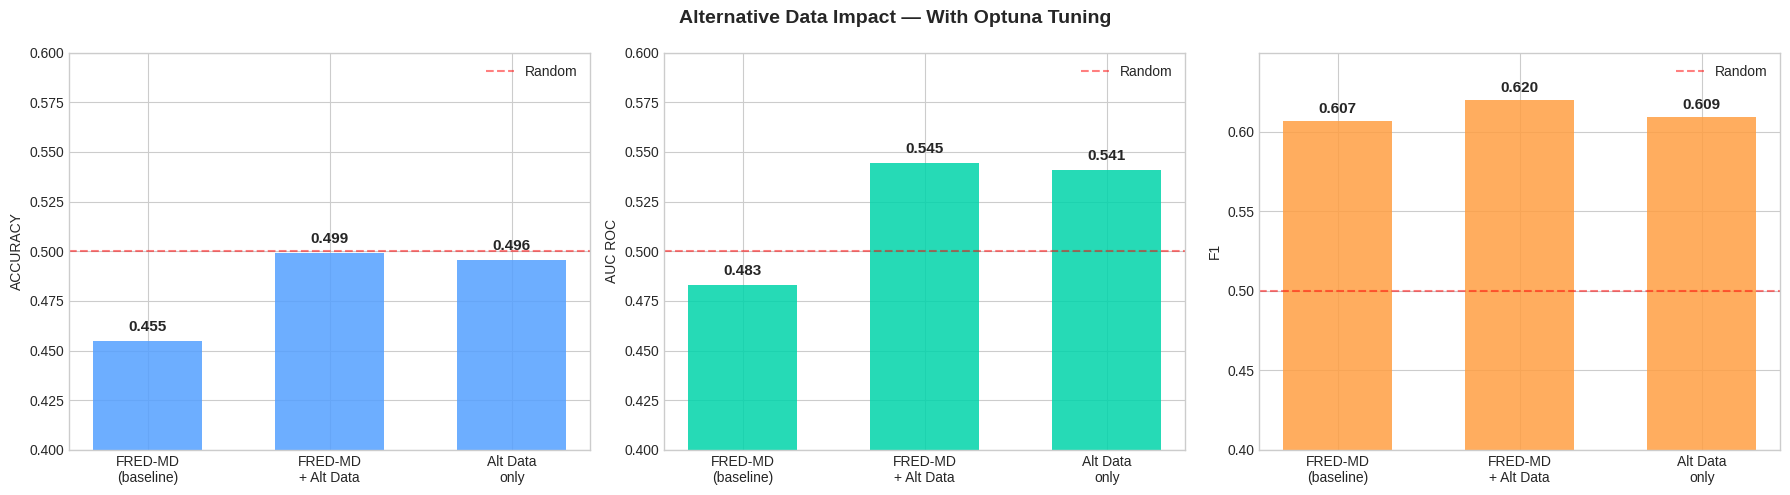

In [12]:
# Bar charts
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric, color in zip(axes, ['accuracy','auc_roc','f1'], ['#54A0FF','#00D4AA','#FF9F43']):
    vals = rdf[metric]
    bars = ax.bar(range(len(vals)), vals.values, color=color, alpha=0.85, width=0.6)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(['FRED-MD\n(baseline)', 'FRED-MD\n+ Alt Data', 'Alt Data\nonly'], fontsize=10)
    ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random')
    ax.set_ylabel(metric.replace('_',' ').upper()); ax.legend()
    ax.set_ylim(0.40, max(0.60, vals.max()+0.03))
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x()+bar.get_width()/2, val+0.005, f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
fig.suptitle('Alternative Data Impact — With Optuna Tuning', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

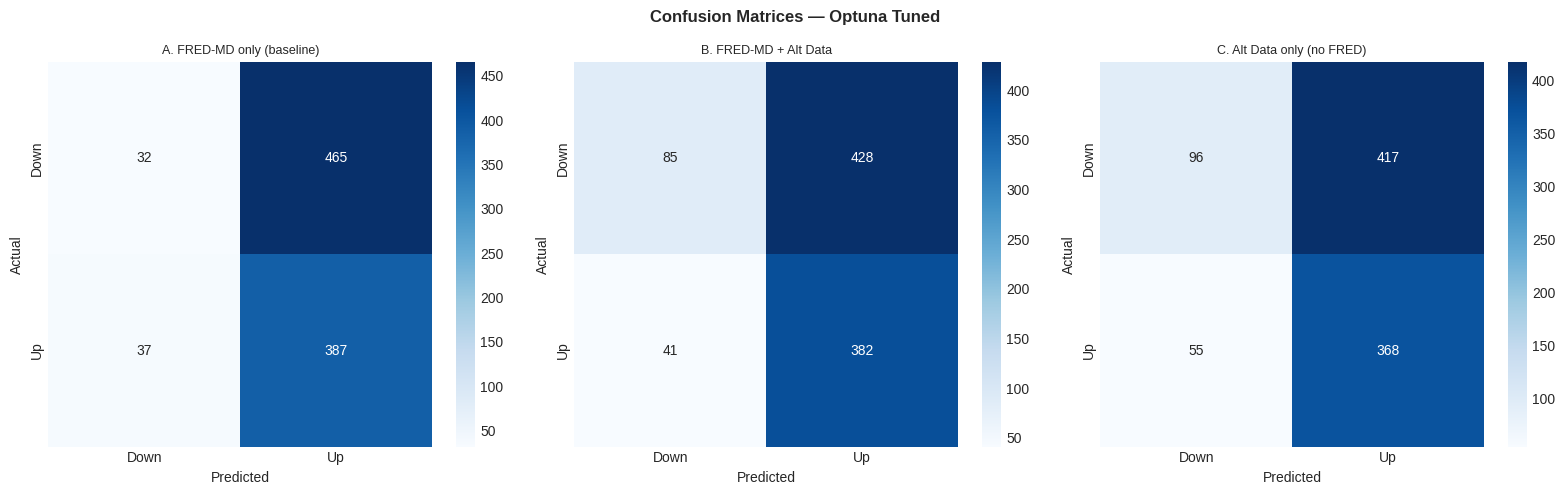

In [13]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, name in zip(axes, experiments.keys()):
    p = all_preds[name]
    cm = confusion_matrix(p['y_test'], p['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Down','Up'], yticklabels=['Down','Up'])
    ax.set_title(name, fontsize=9); ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
plt.suptitle('Confusion Matrices — Optuna Tuned', fontweight='bold')
plt.tight_layout(); plt.show()

In [14]:
# Save
out = str(BASE_DIR / 'alternative_data' / 'processed' / 'v5_optuna_results.csv')
os.makedirs(os.path.dirname(out), exist_ok=True)
rdf.to_csv(out)
print(f'Saved: {out}')
print()
print('Best params per experiment:')
for name, params in [('A', best_A), ('B', best_B), ('C', best_C)]:
    print(f'  {name}: wd={params["weight_decay"]:.6f} h={params["hidden_size"]} L={params["num_layers"]} lr={params["learning_rate"]:.6f} do={params["dropout"]:.3f}')

Saved: /content/drive/MyDrive/Quants /alternative_data/processed/v5_optuna_results.csv

Best params per experiment:
  A: wd=0.000485 h=64 L=2 lr=0.000108 do=0.498
  B: wd=0.001845 h=128 L=1 lr=0.000380 do=0.413
  C: wd=0.000061 h=64 L=1 lr=0.000841 do=0.315
